# Explainable Recommender System with SHAP
### Imports & setup

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from src.hybrid_ranker import HybridRanker, DEFAULT_HYBRID_WEIGHTS
from src.explainability import normalized_weights

ranker = HybridRanker()
weights = normalized_weights(DEFAULT_HYBRID_WEIGHTS)
weights

C:\Python repositories\Project Machine learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'item_knn': 0.5, 'popularity': 0.25, 'genre': 0.25}

### Obtaining recommendations

In [2]:
# Seed
rng = np.random.default_rng(42)

user_ids = ranker.available_user_ids()[:30]
candidate_sample_size = 300
top_n = 10

rows = []
for user_id in user_ids:

    # Seen Movies
    seen_items = ranker.item_engine.user_seen_items.get(user_id, set())

    # Candidate unseen movies
    unseen_items = [
        item for item in ranker.item_engine.item_ids.tolist()
        if item not in seen_items
    ]

    sample_size = min(candidate_sample_size, len(unseen_items))
    candidate_ids = rng.choice(unseen_items, size=sample_size, replace=False).tolist()

    # Ranking only on the sample
    ranked, scores, components = ranker.rank_items(
        user_id=user_id,
        candidate_ids=candidate_ids,
        top_n=top_n
    )

    recs = ranker._format_recommendations(ranked, scores, components)
    recs["userId"] = user_id
    rows.append(recs)

recommendations = pd.concat(rows, ignore_index=True)
recommendations.head()

,movieId,title,genres,relevance_score,item_knn_score,popularity_score,genre_score,explanations,component_contributions,explanation_summary,item_knn_shap,popularity_shap,genre_shap,userId
0,858,"Godfather, The (1972)",Crime | Drama,0.8754,1.0000,1.0000,0.5016,"[{'movieId': 260, 'title': 'Star Wars: Episode...","{'contributions': {'item_knn': 0.5, 'popularit...",Main signal: similarity to movies the user liked.,0.50000,0.250000,0.125400,1
1,6539,Pirates of the Caribbean: The Curse of the Bla...,Action | Adventure | Comedy | Fantasy,0.8735,0.8969,0.7003,1.0000,"[{'movieId': 2571, 'title': 'Matrix, The (1999...","{'contributions': {'item_knn': 0.44845, 'popul...",Main signal: similarity to movies the user liked.,0.44845,0.175075,0.250000,1
2,6377,Finding Nemo (2003),Adventure | Animation | Children | Comedy,0.7907,0.7598,0.7807,0.8624,"[{'movieId': 2571, 'title': 'Matrix, The (1999...","{'contributions': {'item_knn': 0.3799, 'popula...",Main signal: similarity to movies the user liked.,0.37990,0.195175,0.215600,1
3,588,Aladdin (1992),Adventure | Animation | Children | Comedy | Mu...,0.7767,0.7813,0.6900,0.8543,"[{'movieId': 457, 'title': 'Fugitive, The (199...","{'contributions': {'item_knn': 0.39065, 'popul...",Main signal: similarity to movies the user liked.,0.39065,0.172500,0.213575,1
4,1250,"Bridge on the River Kwai, The (1957)",Adventure | Drama | War,0.7520,0.7290,0.8987,0.6512,"[{'movieId': 2944, 'title': 'Dirty Dozen, The ...","{'contributions': {'item_knn': 0.3645, 'popula...",Main signal: similarity to movies the user liked.,0.36450,0.224675,0.162800,1


### SHAP Analysis and Signal Interpretation

In [3]:
# Features used by the hybrid ranker
feature_cols = ["item_knn_score", "popularity_score", "genre_score"]

# Cleaner names for plots
feature_labels = {
    "item_knn_score": "Item-KNN score",
    "popularity_score": "Popularity score",
    "genre_score": "Genre score"
}

# Basic plot styling
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# Extracting the recommendation signals
x_raw = recommendations[feature_cols].astype(float).fillna(0.0)

# Renaming columns (for plotting)
x = x_raw.rename(columns=feature_labels)

# Storing the hybrid weights using the same column order as x
weight_series = pd.Series({
    "Item-KNN score": weights["item_knn"],
    "Popularity score": weights["popularity"],
    "Genre score": weights["genre"]
})

display(weight_series)
display(x.head())

Item-KNN score      0.50
Popularity score    0.25
Genre score         0.25
dtype: float64

,Item-KNN score,Popularity score,Genre score
0,1.0000,1.0000,0.5016
1,0.8969,0.7003,1.0000
2,0.7598,0.7807,0.8624
3,0.7813,0.6900,0.8543
4,0.7290,0.8987,0.6512


### Compute the Hybrid Relevance Score

In [4]:
def predict_hybrid(values):
    values = np.asarray(values, dtype=float)

    if values.ndim == 1:
        values = values.reshape(1, -1)

    return values.dot(weight_series.values)

# Compute the relevance score from the three components
recommendations["computed_relevance_score"] = predict_hybrid(x.values)
recommendations[["userId", "computed_relevance_score"] + feature_cols].head()

,userId,computed_relevance_score,item_knn_score,popularity_score,genre_score
0,1,0.875400,1.0000,1.0000,0.5016
1,1,0.873525,0.8969,0.7003,1.0000
2,1,0.790675,0.7598,0.7807,0.8624
3,1,0.776725,0.7813,0.6900,0.8543
4,1,0.751975,0.7290,0.8987,0.6512


### Raw Signal Distribution

,count,mean,std,min,25%,50%,75%,max
Item-KNN score,300.0,0.779268,0.164763,0.3148,0.683600,0.77625,0.912300,1.0
Popularity score,300.0,0.733844,0.161552,0.2237,0.615925,0.71665,0.867225,1.0
Genre score,300.0,0.685994,0.210630,0.0000,0.545125,0.69080,0.848800,1.0


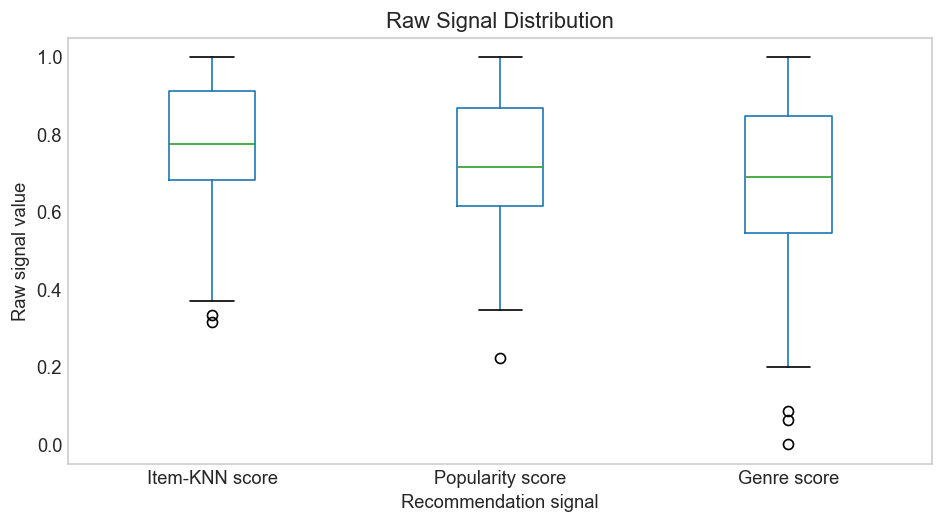

In [8]:
display(x.describe().T)
fig, ax = plt.subplots(figsize=(8, 4.5))

x.boxplot(ax=ax, grid=False)
ax.set_title("Raw Signal Distribution")
ax.set_xlabel("Recommendation signal")
ax.set_ylabel("Raw signal value")
plt.tight_layout()
plt.show()

The boxplots show how the raw feature scores look before any weights are applied. The distributions for all three signals are remarkably similar with medians clustering around 0.7 to 0.8. While the Item-KNN score has a slightly higher median and tighter upper distribution, the model generates consistently strong raw scores across all three categories.

### Weighted Contribution Analysis

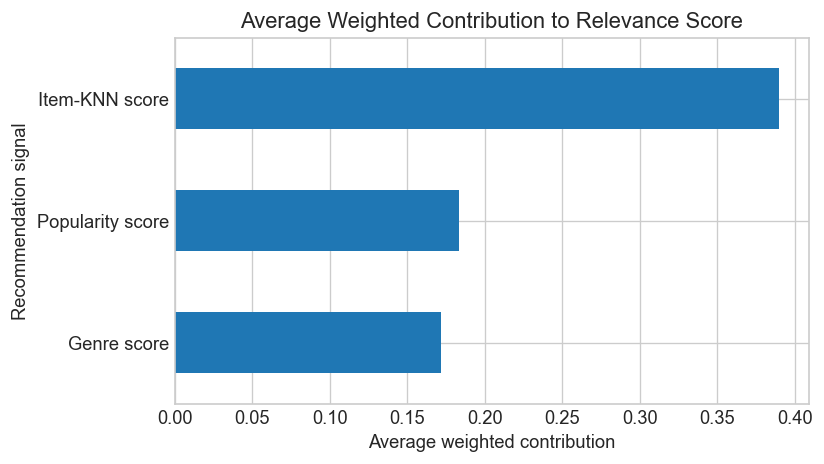

In [20]:
weighted_contributions = x.mul(weight_series, axis=1)
mean_contribution = weighted_contributions.mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
mean_contribution.plot(
    kind="barh",
    ax=ax,
)
ax.set_title("Average Weighted Contribution to Relevance Score")
ax.set_xlabel("Average weighted contribution")
ax.set_ylabel("Recommendation signal")

plt.tight_layout()
plt.show()

The bar chart illustrates the final impact of your weighting strategy (0.5 for KNN, 0.25 for Popularity, 0.25 for Genre). Because the Item-KNN score receives double the weight of the other two features, it heavily dominates the final relevance score, contributing roughly 0.39 on average compared to ~0.17–0.18 for the others.

### SHAP Values

In [12]:
# Mean recommendation as the SHAP background.
background = x.mean().to_frame().T

explainer = shap.Explainer(
    predict_hybrid,
    background,
    feature_names=x.columns.tolist()
)

shap_values = explainer(x)

### Shap Summary Plot

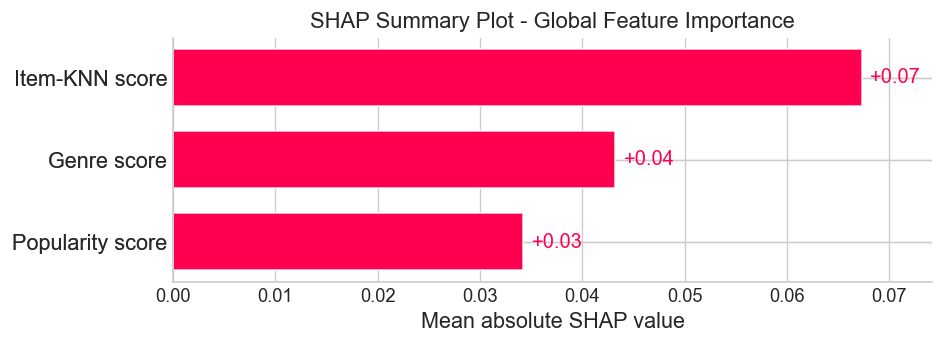

In [14]:
shap.plots.bar(
    shap_values,
    max_display=len(feature_cols),
    show=False
)

plt.title("SHAP Summary Plot - Global Feature Importance")
plt.xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

The SHAP summary plot shows the mean absolute SHAP value of each feature across all recommendations, indicating its overall contribution to the final relevance score. The Item-KNN score has the highest average impact (≈0.07), followed by the Genre score (≈0.04) and the Popularity score (≈0.03). This suggests that variations in the Item-KNN signal influence the final recommendation score more strongly than the other two signals. Overall, the ranking process is driven primarily by collaborative filtering information, while genre similarity and popularity provide additional but smaller contributions.

### SHAP Beeswarm Plot

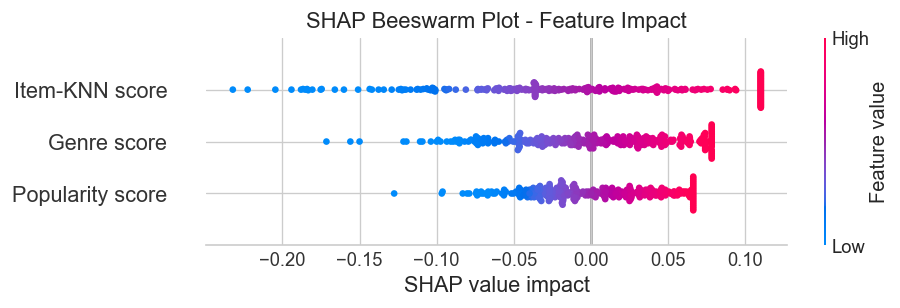

In [16]:
shap.plots.beeswarm(
    shap_values,
    max_display=len(feature_cols),
    show=False
)

plt.title("SHAP Beeswarm Plot - Feature Impact")
plt.xlabel("SHAP value impact")
plt.tight_layout()
plt.show()

The SHAP beeswarm plot illustrates both the magnitude and direction of each feature's impact on the relevance score. Each point represents a recommendation, with color indicating the original feature value (blue for low values and pink for high values). For all three signals, higher feature values are generally associated with positive SHAP values, increasing the recommendation score, while lower feature values tend to decrease it. The wider spread of SHAP values for the Item-KNN score confirms its stronger influence on the ranking process. In contrast, Genre and Popularity scores exhibit smaller but still meaningful contributions to the final recommendations.

### SHAP Waterfall Plots

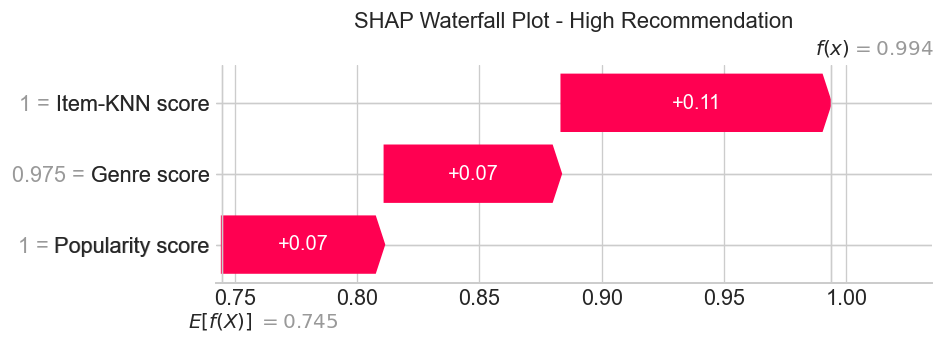

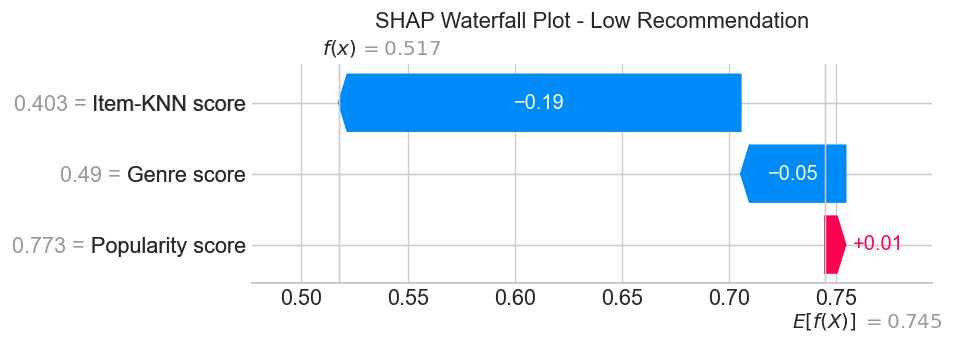

In [18]:
# Selecting a high and a low score recommendation
high_idx = int(np.argmax(recommendations["computed_relevance_score"].values))
low_idx = int(np.argmin(recommendations["computed_relevance_score"].values))

# Waterfall plot for a high score recommendation
shap.plots.waterfall(
    shap_values[high_idx],
    max_display=len(feature_cols),
    show=False
)

plt.title("SHAP Waterfall Plot - High Recommendation")
plt.tight_layout()
plt.show()

# Waterfall plot for a low score recommendation
shap.plots.waterfall(
    shap_values[low_idx],
    max_display=len(feature_cols),
    show=False
)

plt.title("SHAP Waterfall Plot - Low Recommendation")
plt.tight_layout()
plt.show()

* **High score recommendation:**
The waterfall plot for the highest-ranked recommendation explains how the final score is obtained relative to the average prediction. Starting from the baseline value of 0.745, all three features contribute positively to the final score of 0.994. The largest contribution comes from the Item-KNN score (+0.11), followed by the Genre score (+0.07) and the Popularity score (+0.07). This indicates that the recommendation achieved a very high relevance score because it performed strongly across all recommendation signals, with Item-KNN providing the greatest boost.

* **Low score recommendation:**
The waterfall plot for the lowest-ranked recommendation shows the opposite behavior. Starting from the same baseline value of 0.745, the final score decreases to 0.517. The largest negative contribution comes from the Item-KNN score (-0.19), while the Genre score also reduces the prediction (-0.05). The Popularity score contributes only slightly in a positive direction (+0.01), which is insufficient to offset the negative effects of the other features. This suggests that the recommendation received a low relevance score primarily because of weak collaborative filtering and genre similarity signals.

### Conclusion
Overall, the SHAP analysis provides a transparent decomposition of the hybrid relevance score by quantifying the contribution of each recommendation signal to the final prediction. The results show that Item-KNN contributes the most to score variations, followed by genre similarity and popularity. However, because the hybrid ranker is based on a predefined weighted linear combination of features, the SHAP values primarily reflect how each signal contributes to the final score rather than revealing complex relationships or interactions between features. Therefore, in this context, SHAP serves mainly as an explanation tool for the ranking decisions, offering both global and local interpretability of recommendations, rather than uncovering previously unknown feature dependencies.